# Feature Engineering Methods

# Create Features

In [2]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv("../data/cleaned_timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

In [3]:
df

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0
...,...,...
449,2014-03-27,328.0
450,2014-03-28,523.0
451,2014-03-29,647.0
452,2014-03-30,599.0


In [4]:
# Lag features (per store and item)
df['lag_1'] = df['unit_sales'].shift(1)
df['lag_7'] = df['unit_sales'].shift(7)
df['lag_30'] = df['unit_sales'].shift(30)

# Rolling statistics
df['rolling_std_7'] = df['unit_sales'].shift(1).rolling(window=7).std()


In [5]:

df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)


In [7]:
df.to_csv("../data/feature_engineered_timeseries.csv", index=False)

# ML Part

In [9]:
split_date = '2014-01-01'
train = df[df['date'] <= split_date]
test = df[df['date'] > split_date]

In [10]:
# Define target variable (unit_sales) and features
X_train = train.drop('unit_sales', axis=1)
X_train = X_train.drop('date', axis=1)
y_train = train['unit_sales']

X_test = test.drop('unit_sales', axis=1)
X_test = X_test.drop('date', axis=1)
y_test = test['unit_sales']

In [12]:
y_train

0      582.0
1      310.0
2      338.0
3      654.0
4      979.0
       ...  
360    499.0
361    552.0
362    595.0
363    436.0
364    436.0
Name: unit_sales, Length: 365, dtype: float64

## XGBoost Model

In [13]:
# Initialize the XGBoost regressor
xgboost_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    enable_categorical=True
)

# Train the XGBoost model
xgboost_model.fit(X_train, y_train)
# Make predictions on the test set
y_pred = xgboost_model.predict(X_test)

 MAE: 106.60230109396946, MSE: 23843.04969186271, R2: 0.2990499022283605


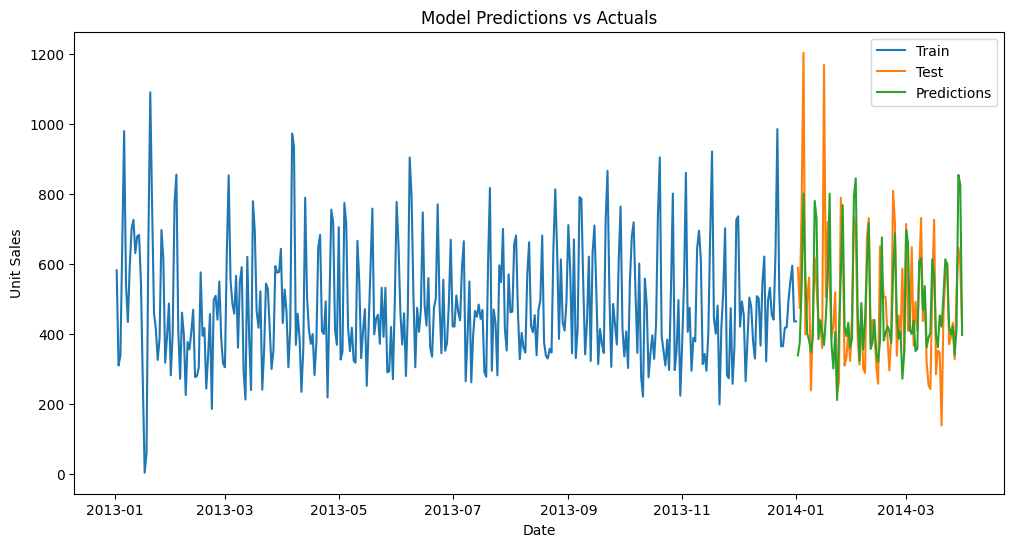

In [14]:

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f" MAE: {mae}, MSE: {mse}, R2: {r2}")
# visualize predictions against actuals and whole serie

plt.figure(figsize=(12, 6))
plt.plot(train['date'], train['unit_sales'], label='Train')
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(test['date'], y_pred, label='Predictions')
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()


## Sklearn Models

In [22]:
# If you are using models that do not handle missing values, you can drop rows with NaN values in the training set
"""
X_train = X_train.dropna()
y_train = y_train[X_train.index]
"""



In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Initialize models
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42) # You can switch to LinearRegression() or SVR() to test other models

# Train the model
model.fit(X_train.dropna(), y_train)
# Make predictions
y_pred = model.predict(X_test)


In [24]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f" MAE: {mae}, MSE: {mse}, R2: {r2}")

 MAE: 93.65054490500472, MSE: 19993.012589032598, R2: 0.4122352505176873


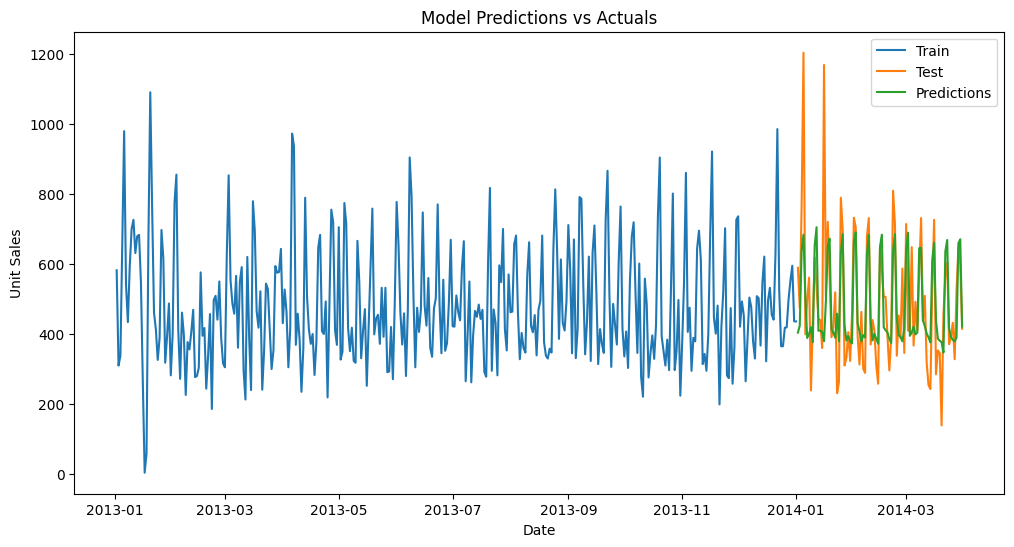

In [25]:
# visualize predictions against actuals and whole serie

plt.figure(figsize=(12, 6))
plt.plot(train['date'], train['unit_sales'], label='Train')
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(test['date'], y_pred, label='Predictions')
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()
